Sara Hernandez Ochoa y Migel Aaron Ochoa

## <font color='white'>Tarea 4.</font>

<font color='white'>
Realiza un análisis para un portafolio compuesto por los siguientes activos: <b>LLY (Eli Lilly), NVDA (NVIDIA), MSFT (Microsoft) y KXI (iShares Global Consumer Staples ETF)</b>. Completa los siguientes puntos.
</font>

---

### <font color='white'>1. Investigación de los Activos</font>

<font color='white'>
Realiza un breve resumen de los activos, describiendo su giro de negocio, sector y productos o servicios.
</font>

---

### <font color='white'>2. Cálculo de Rendimientos y Volatilidad de Activos</font>

<font color='white'>
Descarga los <b>precios de cierre ajustado</b> para los activos desde el <code>2018-01-01</code> hasta el <code>2024-09-25</code>, calcula los <b>rendimientos diarios</b>, así como el <b>rendimiento promedio</b>, la <b>volatilidad</b> de cada activo y la <b>matriz de covarianza</b>.
</font>

---

### <font color='white'>3. Portafolio Eficiente en Mínima Varianza</font>

<font color='white'>
Utilizando la matriz de covarianza de los activos, optimiza los pesos para obtener el <b>portafolio de mínima varianza</b>. Calcula su rendimiento y volatilidad.
</font>

---

### <font color='white'>4. Portafolio Eficiente en Máximo Sharpe</font>

<font color='white'>
Obtén el portafolio que <b>maximiza el ratio de Sharpe</b>, calcula su rendimiento y volatilidad. Asume una tasa libre de riesgo del 3% anual.
</font>

---

### <font color='white'>5. Portafolio Equitativamente Ponderado</font>

<font color='white'>
Asume otro portafolio equitativamente ponderado (todos los activos con el mismo peso), y calcula su rendimiento promedio y su volatilidad.
</font>

---

### <font color='white'>6. Gráfica de la Frontera Eficiente</font>

<font color='white'>
Grafica la <b>frontera eficiente</b> en términos de media-varianza, junto con los portafolios eficientes, el portafolio equitativamente ponderado y los activos individuales.
</font>

---

### <font color='white'>7. Conclusión</font>

<font color='white'>
Compara las métricas de rendimiento y volatilidad de los tres portafolios:
</font>

<font color='white'>
1. Portafolio de mínima varianza  
2. Portafolio de máximo Sharpe  
3. Portafolio equitativamente ponderado  
</font>

<font color='white'>
Responde:
</font>

<font color='white'>
- ¿Cuál de estos portafolios es superior en términos de riesgo?  
- ¿Cuál de estos portafolios es superior en términos de riesgo y retorno?  
- Interpreta la frontera eficiente en base a la teoría vista en clase y responde: ¿Qué pasa con el portafolio equally weighted? ¿Es óptimo? ¿Por qué?  
- ¿Por qué un portafolio podría ser mejor que otro? ¿De qué depende que sea "mejor"?  
- Analiza las ponderaciones obtenidas por el método de mínima varianza y el de máximo de Sharpe para cada activo de manera individual, basándote en la descripción presentada en la primera sección de la tarea. ¿Qué factores explican que cada activo tenga una mayor o menor ponderación en uno de los métodos en comparación con el otro?  
- Concluye acerca de las ventajas y desventajas de una estrategia cuantitativa de asignación de activos frente a una basada en "feeling" o intuición.
</font>

# **1**

# **2**

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [3]:
# Obtener precios
tickers = ['LLY', 'NVDA', 'MSFT', 'KXI']
prices = yf.download(tickers, start='2018-01-01', end='2024-09-25')['Close']

[*********************100%***********************]  4 of 4 completed


In [4]:
# Obtener rendimiento
rets = prices.pct_change().dropna()
rets

Ticker,KXI,LLY,MSFT,NVDA
Date,,,,
2018-01-03,0.000095,0.005432,0.004654,0.065814
2018-01-04,0.002180,0.004463,0.008802,0.005271
2018-01-05,0.006431,0.012278,0.012398,0.008474
2018-01-08,-0.000376,-0.005083,0.001021,0.030641
2018-01-09,-0.002068,-0.000813,-0.000680,-0.000270
...,...,...,...,...
2024-09-18,-0.005034,-0.001335,-0.009973,-0.019206
2024-09-19,-0.001073,0.011127,0.018291,0.039693
2024-09-20,-0.001688,0.007049,-0.007796,-0.015865


In [5]:
# Obtener rendimiento promedio
rend_mean=rets.mean()
rend_mean

Ticker
KXI     0.000265
LLY     0.001653
MSFT    0.001164
NVDA    0.002429
dtype: float64

In [6]:
# Obtener matriz de covarianza
cov=rets.cov()
cov

Ticker,KXI,LLY,MSFT,NVDA
Ticker,,,,
KXI,0.000088,0.000074,0.000104,0.000123
LLY,0.000074,0.000353,0.000130,0.000158
MSFT,0.000104,0.000130,0.000338,0.000403
NVDA,0.000123,0.000158,0.000403,0.001075


# **3**

In [7]:
# Definir funcion objetivo 
def varianza(w):
    return w.T @ cov @ w
# la siguiente varianza
varianza= lambda w: w.T @ cov @ w

In [8]:
# Definir valores iniciales
n_assets=len(tickers)
w_inicial=np.ones(n_assets)/n_assets
w_inicial

array([0.25, 0.25, 0.25, 0.25])

In [9]:
# Definir las cotas
rangos=[(0,1)]*(n_assets)
rangos

[(0, 1), (0, 1), (0, 1), (0, 1)]

In [10]:
# Definir las restricciones
r1= lambda w: sum(w) -1


In [11]:
# definir tolerancia 
tol=1e-50

In [12]:
# aplicar funcion de scipy.optimize
result=minimize(fun=varianza, x0=w_inicial, bounds=rangos,
                constraints={'fun': r1, 'type': 'eq'}, tol=tol)
result

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 8.707206249440109e-05
           x: [ 9.536e-01  4.643e-02  2.737e-18  3.117e-19]
         nit: 20
         jac: [ 1.741e-04  1.741e-04  2.102e-04  2.488e-04]
        nfev: 106
        njev: 19
 multipliers: [ 1.741e-04]

In [13]:
## Encontrar pesos eficientes
w_opt_min_var = result.x
dict(zip(prices.columns, w_opt_min_var))

{'KXI': np.float64(0.9535668840943062),
 'LLY': np.float64(0.046433115905693774),
 'MSFT': np.float64(2.737007245084844e-18),
 'NVDA': np.float64(3.1171523477908013e-19)}

In [14]:
# Obtener rendimiento del portafoliio 
R_min_var = w_opt_min_var @ rets.mean()
R_min_var

np.float64(0.0003297828655596045)

In [15]:
# obtener volatilidad del portafolio
vol_min_var = np.sqrt(w_opt_min_var @ cov @ w_opt_min_var)
vol_min_var

np.float64(0.009331241208671067)

In [16]:
# Programar funcion:
def opt_min_var(rets:pd.DataFrame) -> np.array:
    # inputs
    cov=rets.cov()
    n = len(rets.columns)
    #funcion
    varianza=lambda w: w.T @ cov @ w
    # tolerancia
    tol=1e-50
    # restricciones
    restriccion= lambda w: sum(w) -1
    # rangos o bounds
    rangos=[(0,1)]*n
    # valore4s iniciales
    w_inicial=np.ones(n)/n# optimizacion
    opt=minimize(fun=varianza, tol=tol, bounds=rangos, x0=w_inicial,
                 constraints={'fun':restriccion, 'type':'eq'})
    print(opt)
    return opt.x

In [17]:
# verificar resultados de la funcion 
opt_min_var(rets)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 8.707206249440109e-05
           x: [ 9.536e-01  4.643e-02  2.737e-18  3.117e-19]
         nit: 20
         jac: [ 1.741e-04  1.741e-04  2.102e-04  2.488e-04]
        nfev: 106
        njev: 19
 multipliers: [ 1.741e-04]


array([9.53566884e-01, 4.64331159e-02, 2.73700725e-18, 3.11715235e-19])

# **4**

In [18]:
# Programar funcion 
def opt_max_sharpe (rets:pd.DataFrame, rf:float) -> np.array:
    # inputs
    cov= rets.cov()
    n= len(rets.columns)
    rets_mean=rets.mean()
    #funcion
    sharpe=lambda w: -((w.T @ rets_mean - rf)/np.sqrt(w.T @cov @w))
    #tolerancia
    tol=1e-50
    # restricciones
    restriccion=lambda w: sum(w)-1
    #rangos o bounds
    rangos=[(0,1)]*n
    #valores iniciales
    w_inicial=np.ones(n)/n#optimizacion
    opt=minimize(fun=sharpe,tol=tol,bounds=rangos,x0=w_inicial,
                 constraints={'fun':restriccion, 'type':'eq'})
    print(opt)
    return opt.x

In [19]:
# obtener los pesos 
risk_free=.0361/252
w_max_sharpe=opt_max_sharpe(rets,risk_free)
dict(zip(rets.columns, w_max_sharpe))

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.09507134373716844
           x: [ 0.000e+00  6.897e-01  4.707e-17  3.103e-01]
         nit: 12
         jac: [ 1.062e-02 -7.782e-03 -3.027e-03 -7.782e-03]
        nfev: 71
        njev: 12
 multipliers: [-7.782e-03]


{'KXI': np.float64(0.0),
 'LLY': np.float64(0.6897411309694331),
 'MSFT': np.float64(4.7071283191479136e-17),
 'NVDA': np.float64(0.3102588690305668)}

In [20]:
# obtener rendimiento de portafolio
R_max_sharpe=sum(w_max_sharpe * rets.mean())
R_max_sharpe

0.0018933750737847605

In [21]:
# Obtener volatilidad del portafolio 
vol_max_sharpe=np.sqrt(w_max_sharpe.T @ cov @ w_max_sharpe)
vol_max_sharpe

np.float64(0.018408502885676338)

# **5**

In [22]:
# Portafolio Equitativamente Ponderado

# Pesos iguales
w_equal = np.ones(n_assets) / n_assets

# Rendimiento promedio
R_equal = w_equal @ rets.mean()

# Volatilidad
vol_equal = np.sqrt(w_equal @ cov @ w_equal)

R_equal, vol_equal

(np.float64(0.0013775728662390127), np.float64(0.015485197038416698))

# **6**

In [23]:
# Generacion de portafolios aleatorios
n_port = 5000
waleatorio = np.random.dirichlet(np.ones(len(rets.columns)), size=n_port)

# Calcular las caracteristicas
rendaleatorios = []
volaleatorios = []
for w in waleatorio:
    rendaleatorios.append(sum(w * rets.mean()))
    volaleatorios.append(np.sqrt(w.T @ cov @ w))

C:\Users\Sarah\AppData\Local\Temp\ipykernel_15548\782314894.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rend_ind = rend_mean[i]


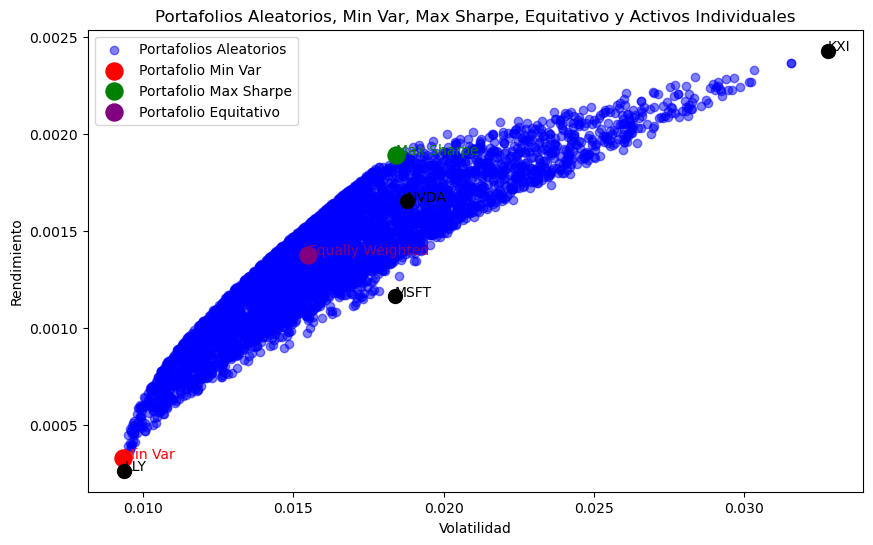

In [24]:
# Realizar gráfica
plt.figure(figsize=(10, 6))

# Scatter plot de portafolios aleatorios
plt.scatter(volaleatorios, rendaleatorios, 
            c='blue', alpha=0.5, 
            label='Portafolios Aleatorios')

# Scatter plot de Mínima Varianza
plt.scatter(vol_min_var, R_min_var, 
            c='red', s=150, 
            label='Portafolio Min Var')
plt.text(vol_min_var, R_min_var, 
         'Min Var', c='red')

# Scatter plot de Máximo Sharpe
plt.scatter(vol_max_sharpe, R_max_sharpe, 
            c='green', s=150, 
            label='Portafolio Max Sharpe')
plt.text(vol_max_sharpe, R_max_sharpe, 
         'Max Sharpe', c='green')

# 🔵 Scatter plot de Portafolio Equitativo
plt.scatter(vol_equal, R_equal, 
            c='purple', s=150, 
            label='Portafolio Equitativo')
plt.text(vol_equal, R_equal, 
         'Equally Weighted', c='purple')

# Graficar activos individuales
for i, ticker in enumerate(tickers):
    vol_ind = np.sqrt(cov.iloc[i, i])
    rend_ind = rend_mean[i]
    
    plt.scatter(vol_ind, rend_ind, 
                c='black', marker='o', s=100)
    plt.text(vol_ind, rend_ind, ticker)

# Nombrar ejes y título
plt.xlabel('Volatilidad')
plt.ylabel('Rendimiento')
plt.title('Portafolios Aleatorios, Min Var, Max Sharpe, Equitativo y Activos Individuales')

plt.legend()
plt.show()

# **7**

- **¿Cuál de estos portafolios es superior en términos de riesgo?** 
- **¿Cuál de estos portafolios es superior en términos de riesgo y retorno?** 
- **Interpreta la frontera eficiente en base a la teoría vista en clase y responde: ¿Qué pasa con el portafolio equally weighted? ¿Es óptimo? ¿Por qué?**
- **¿Por qué un portafolio podría ser mejor que otro? ¿De qué depende que sea "mejor"?**  
- **Analiza las ponderaciones obtenidas por el método de mínima varianza y el de máximo de Sharpe para cada activo de manera individual, basándote en la descripción presentada en la primera sección de la tarea. ¿Qué factores explican que cada activo tenga una mayor o menor ponderación en uno de los métodos en comparación con el otro?**  
- **Concluye acerca de las ventajas y desventajas de una estrategia cuantitativa de asignación de activos frente a una basada en "feeling" o intuición.**